### 1. Import packages

In [1]:
import os, sys, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import PyTorchClassifier

from art_generator import (
    FGSMAttackGenerator, PGDAttackGenerator, DeepFoolAttackGenerator,
    CWAttackGenerator, ZooAttackGenerator, HSJAAttackGenerator,
    MIMAttackGenerator,
)
from utils.masking import get_mutate_indices
from utils.paths import load_attack_config, load_adv_training_config

### 2. Model architecture & Scaled wrapper

In [2]:
class _ResidualBlock(nn.Module):
    def __init__(self, d_in, d_hid, p=0.25):
        super().__init__()
        self.lin1 = nn.Linear(d_in, d_hid)
        self.bn1  = nn.BatchNorm1d(d_hid)
        self.lin2 = nn.Linear(d_hid, d_in)
        self.ln2  = nn.LayerNorm(d_in)
        self.drop = nn.Dropout(p)
    def forward(self, x):
        h = self.drop(torch.relu(self.bn1(self.lin1(x))))
        return torch.relu(self.ln2(x + self.lin2(h)))

class _ResDNN(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        W = 512
        self.stem   = nn.Sequential(nn.Linear(in_dim, W), nn.BatchNorm1d(W), nn.ReLU(), nn.Dropout(0.30))
        self.block1 = _ResidualBlock(W, W // 2, p=0.30)
        self.block2 = _ResidualBlock(W, W // 2, p=0.25)
        self.block3 = _ResidualBlock(W, W // 2, p=0.20)
        self.head   = nn.Linear(W, n_classes)
    def forward(self, x):
        return self.head(self.block3(self.block2(self.block1(self.stem(x)))))

class _ScaledResDNN(nn.Module):
    """Wraps _ResDNN with embedded StandardScaler so ART operates in raw feature space."""
    def __init__(self, resdnn, mean, scale):
        super().__init__()
        self.resdnn = resdnn
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        x = x.float()
        x_scaled = (x - self.mean_) / self.scale_
        return self.resdnn(x_scaled)

### 3. Load model and test data

In [3]:
DEVICE = 'cpu'  # change to 'cuda' if GPU available

# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

# Metadata for art_generator
input_metadata = {'feature_names': feature_names, 'label_column': 'Label'}

# Masking: protect binary/categorical features
mutate_indices = get_mutate_indices(df_test)
print(f'Protected features (binary/categorical): {len(mutate_indices)} indices')

# Load ResDNN checkpoint
ckpt = torch.load('../../training/models/framework_resdnn_TVAE.pth', map_location=DEVICE, weights_only=False)

resdnn_net = _ResDNN(
    in_dim=int(ckpt['in_dim']),
    n_classes=int(ckpt['n_classes']),
)
resdnn_net.load_state_dict(ckpt['state_dict'])
resdnn_net.eval()

scaled_model = _ScaledResDNN(resdnn_net, ckpt['scaler'].mean_, ckpt['scaler'].scale_).to(DEVICE)
scaled_model.eval()

num_classes = int(ckpt['n_classes'])
input_dim = int(ckpt['in_dim'])

Protected features (binary/categorical): 12 indices


In [4]:
# Create ART classifier
classifier = PyTorchClassifier(
    model=scaled_model,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

predictions = classifier.predict(X_test)
original_preds = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_test, original_preds)
print(f'Original Accuracy: {accuracy * 100:.2f}%')

Original Accuracy: 68.89%


In [5]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'ResDNN {attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

### 4. Evaluate original model on adversarial test samples

--- FGSM (before AT) ---
Accuracy: 24.31%
Precision: 40.56%
Recall: 24.31%
F1 Score: 0.2177


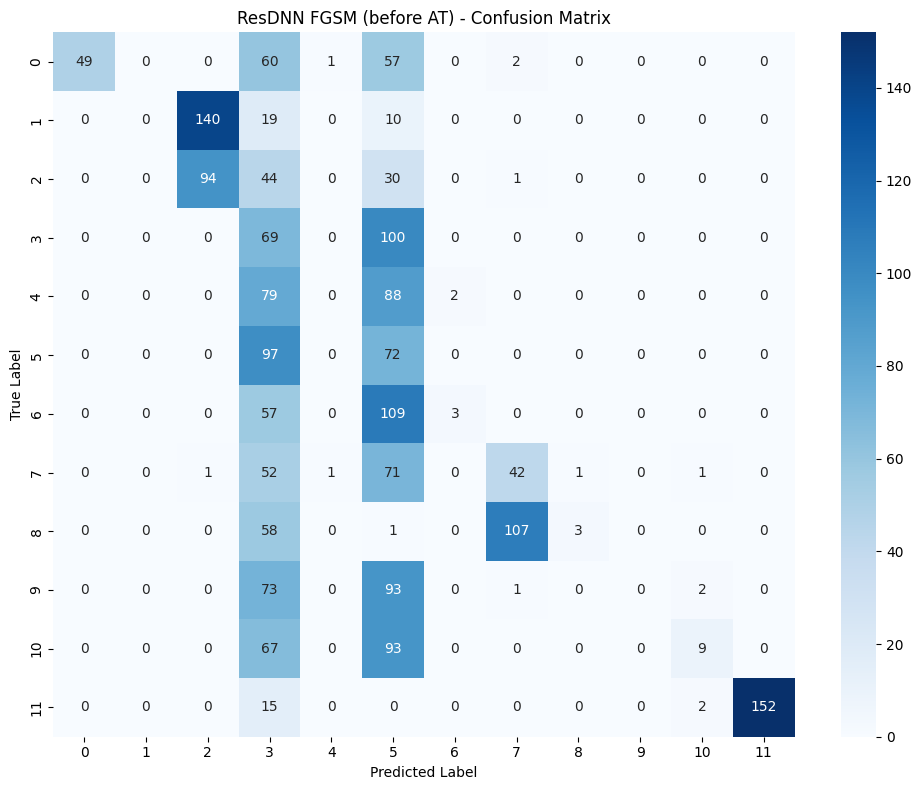

--- PGD (before AT) ---
Accuracy: 20.76%
Precision: 30.34%
Recall: 20.76%
F1 Score: 0.2070


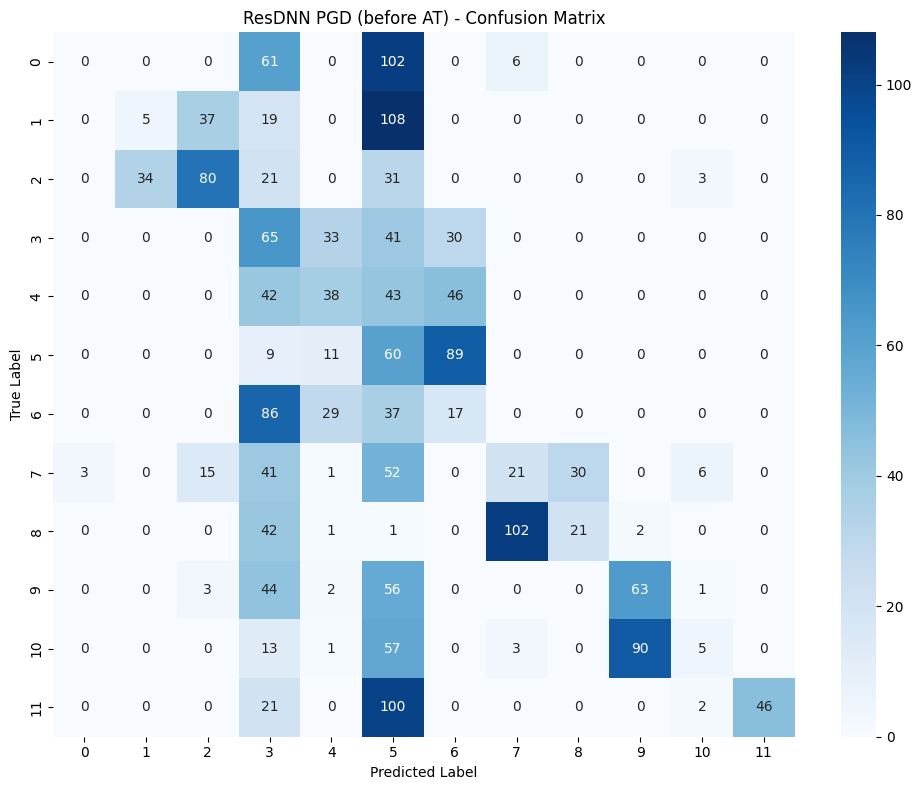

--- DEEPFOOL (before AT) ---
Accuracy: 3.60%
Precision: 4.86%
Recall: 3.60%
F1 Score: 0.0126


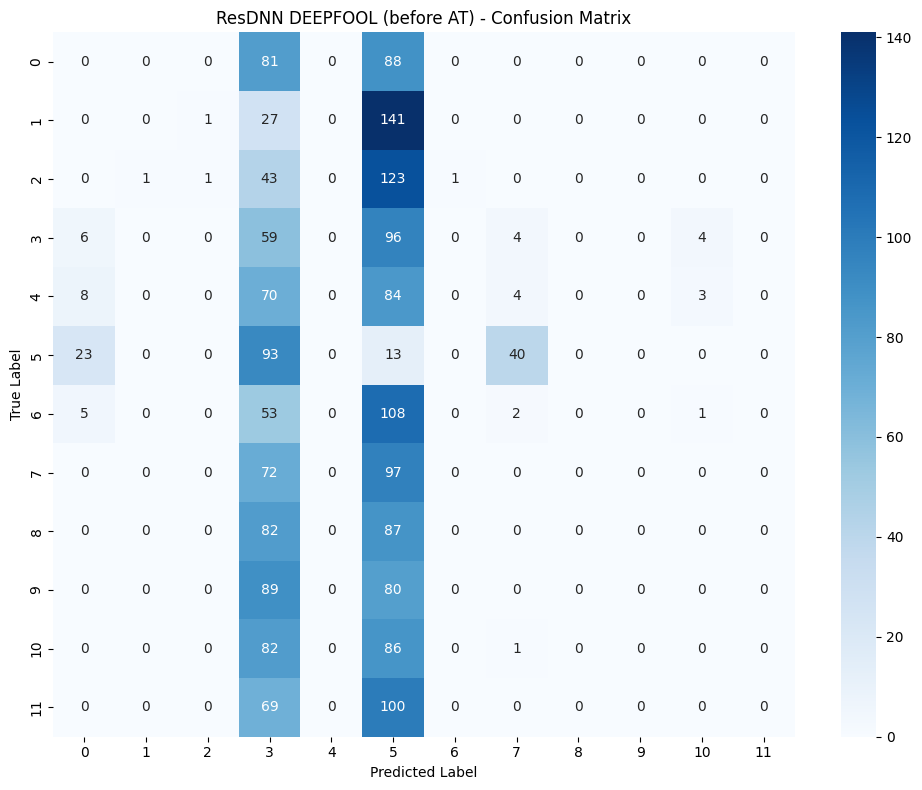

--- CW (before AT) ---
Accuracy: 41.81%
Precision: 45.45%
Recall: 41.81%
F1 Score: 0.3987


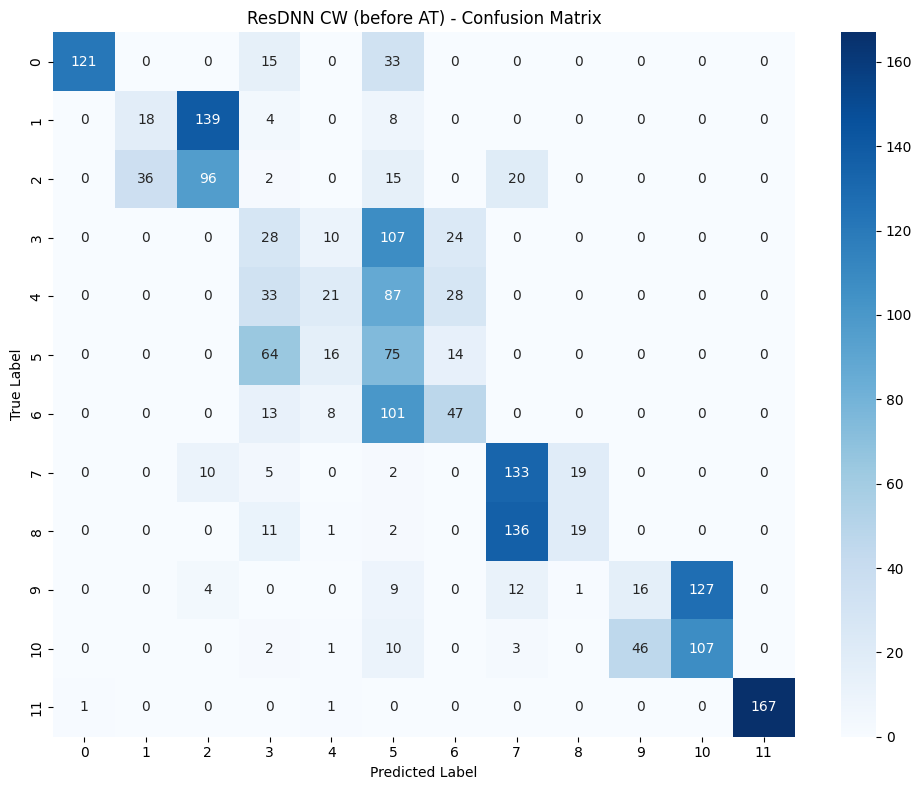

[SKIP] ../../adv_samples/adv_eval/resdnn/resdnn_mim_adv.csv not found
--- ZOO (before AT) ---
Accuracy: 17.41%
Precision: 37.59%
Recall: 17.41%
F1 Score: 0.1674


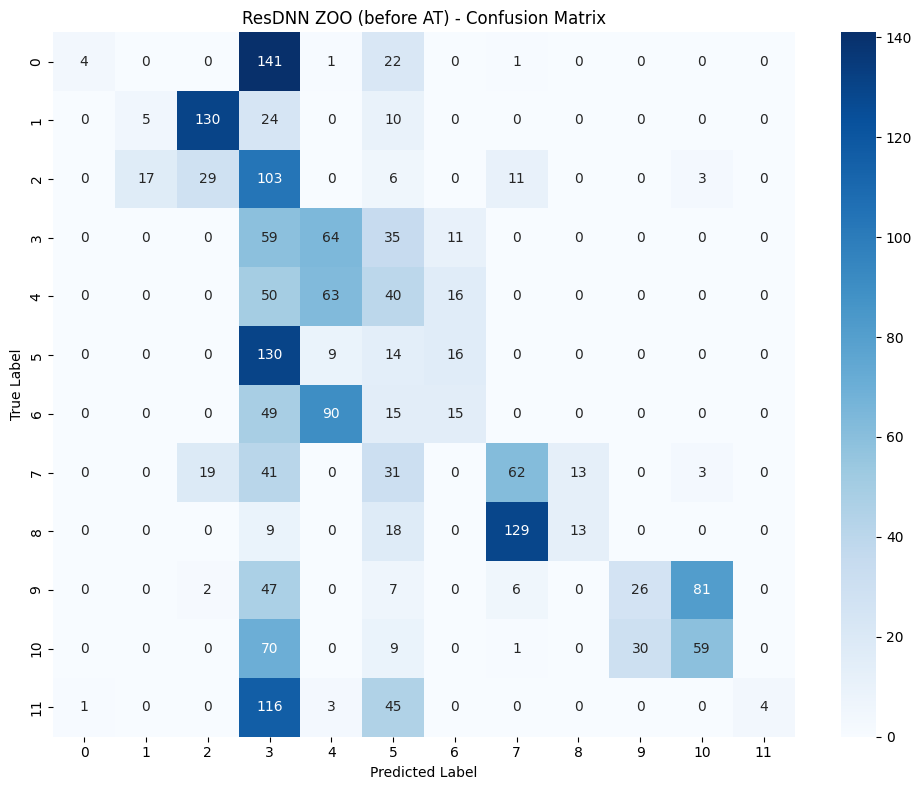

--- HSJA (before AT) ---
Accuracy: 16.67%
Precision: 12.80%
Recall: 16.67%
F1 Score: 0.1252


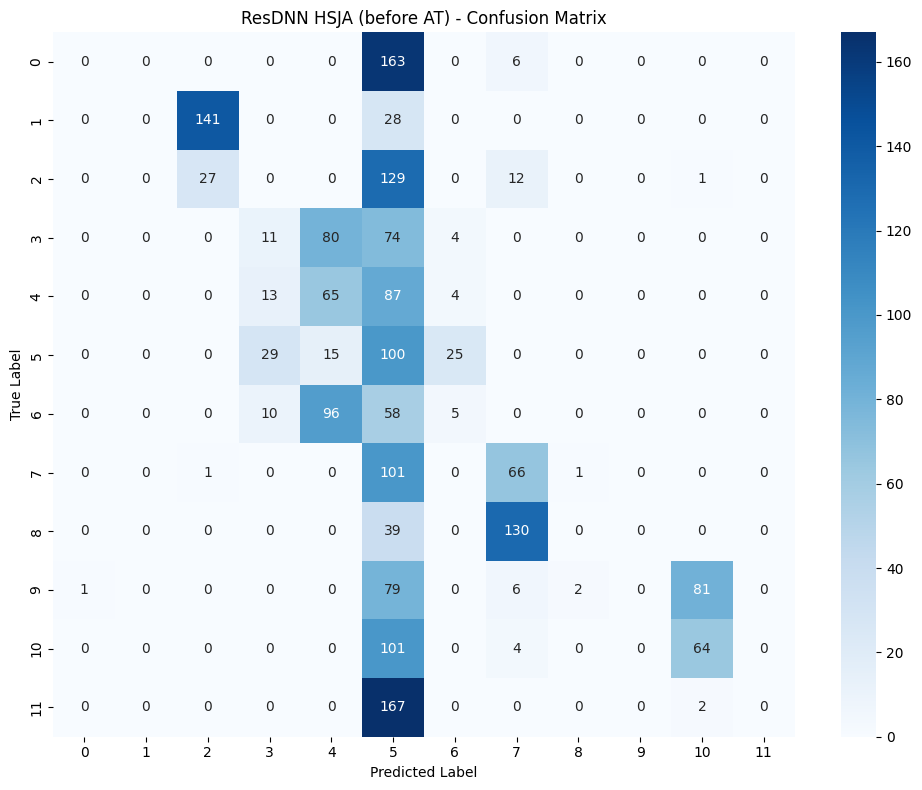

In [6]:
isolated_adv_dir = '../../adv_samples/adv_eval/resdnn/'
attack_names = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim', 'zoo', 'hsja']

adv_eval_data = {}

for atk in attack_names:
    path = os.path.join(isolated_adv_dir, f'resdnn_{atk}_adv.csv')
    if os.path.exists(path):
        df_adv = pd.read_csv(path)
        adv_eval_data[atk] = df_adv.drop(columns=['Label']).values.astype(np.float32)
        preds_adv = classifier.predict(adv_eval_data[atk])
        evaluate_attack(y_test, preds_adv, f'{atk.upper()} (before AT)')
    else:
        print(f'[SKIP] {path} not found')

--- FGSM (before AT) ---
Accuracy: 20.46%
Precision: 42.30%
Recall: 20.46%
F1 Score: 0.1852


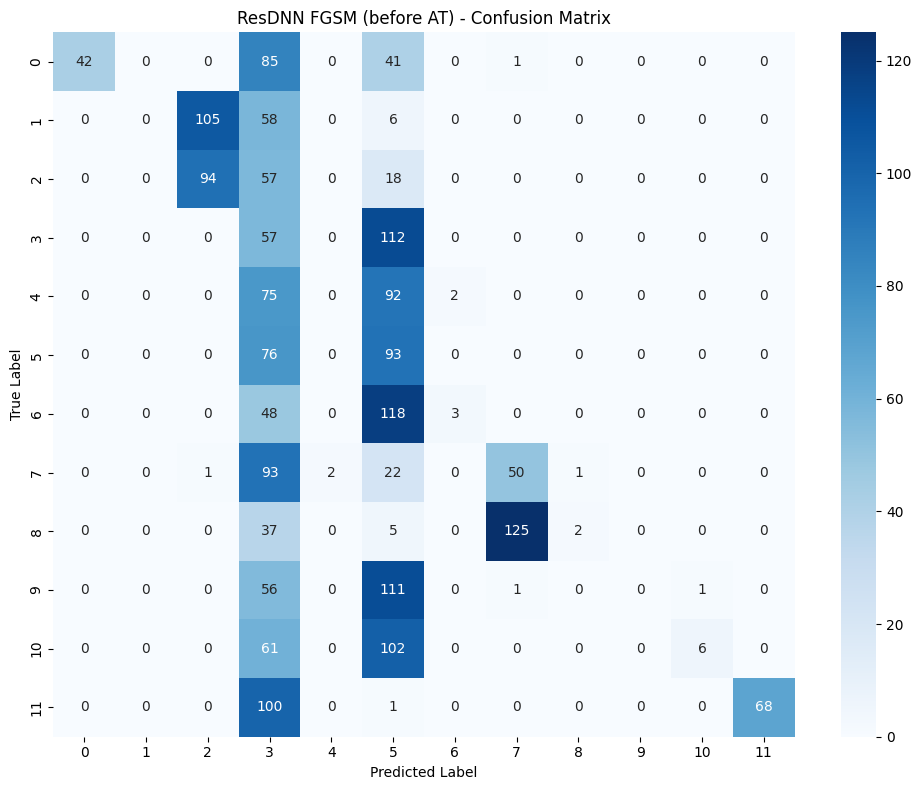

--- PGD (before AT) ---
Accuracy: 33.09%
Precision: 54.69%
Recall: 33.09%
F1 Score: 0.3160


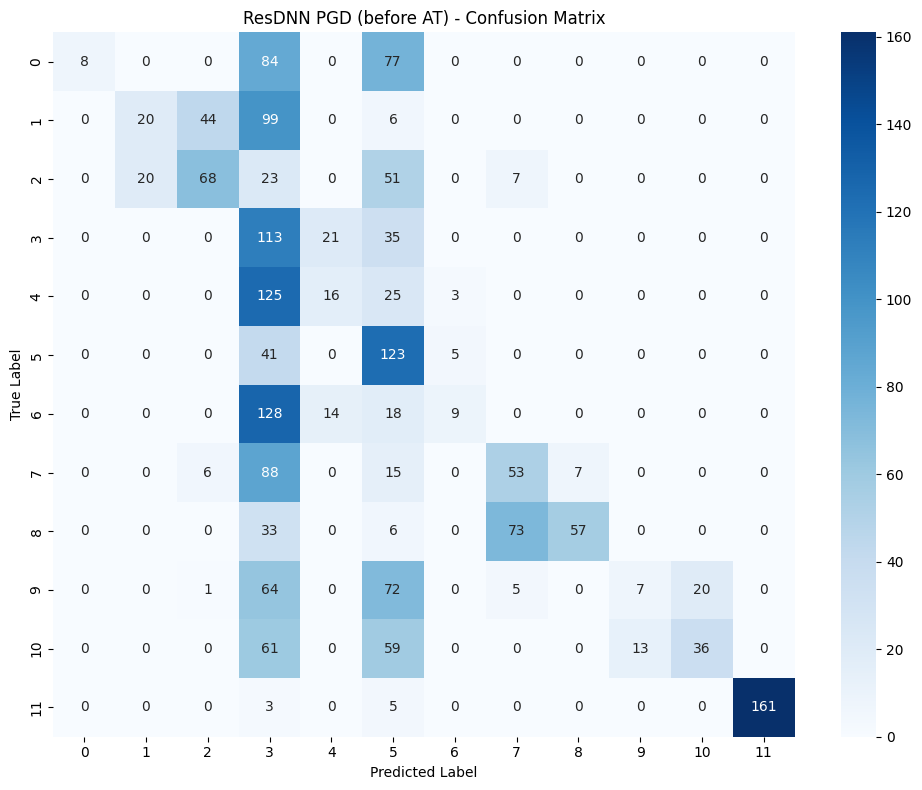

--- DEEPFOOL (before AT) ---
Accuracy: 2.66%
Precision: 6.10%
Recall: 2.66%
F1 Score: 0.0109


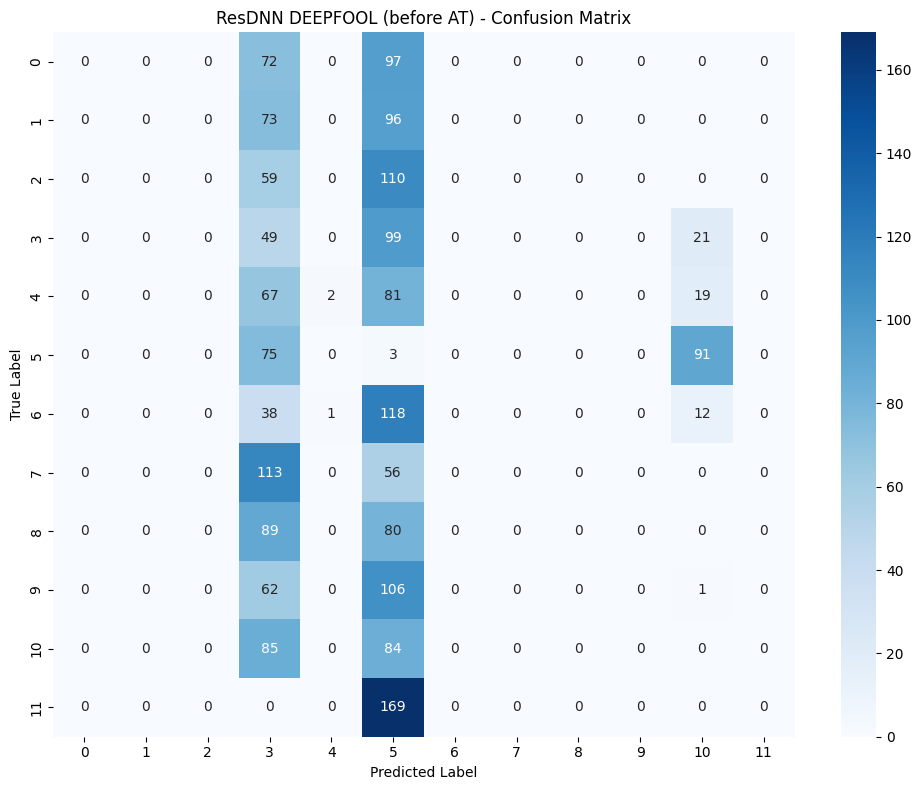

--- CW (before AT) ---
Accuracy: 46.40%
Precision: 52.95%
Recall: 46.40%
F1 Score: 0.4366


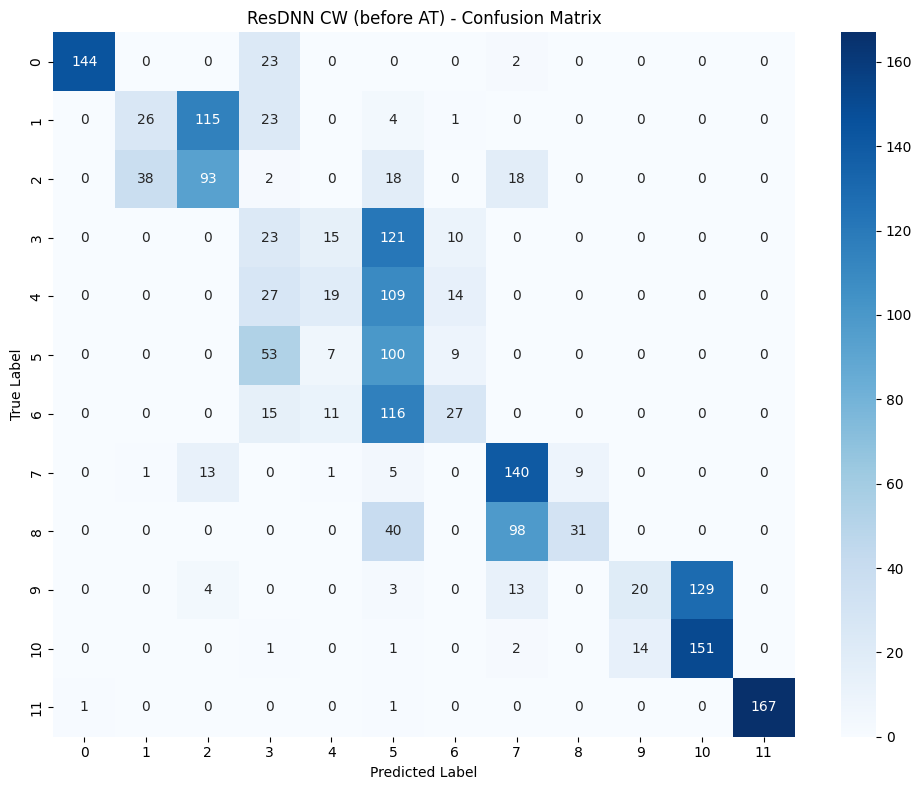

--- MIM (before AT) ---
Accuracy: 14.20%
Precision: 33.88%
Recall: 14.20%
F1 Score: 0.1193


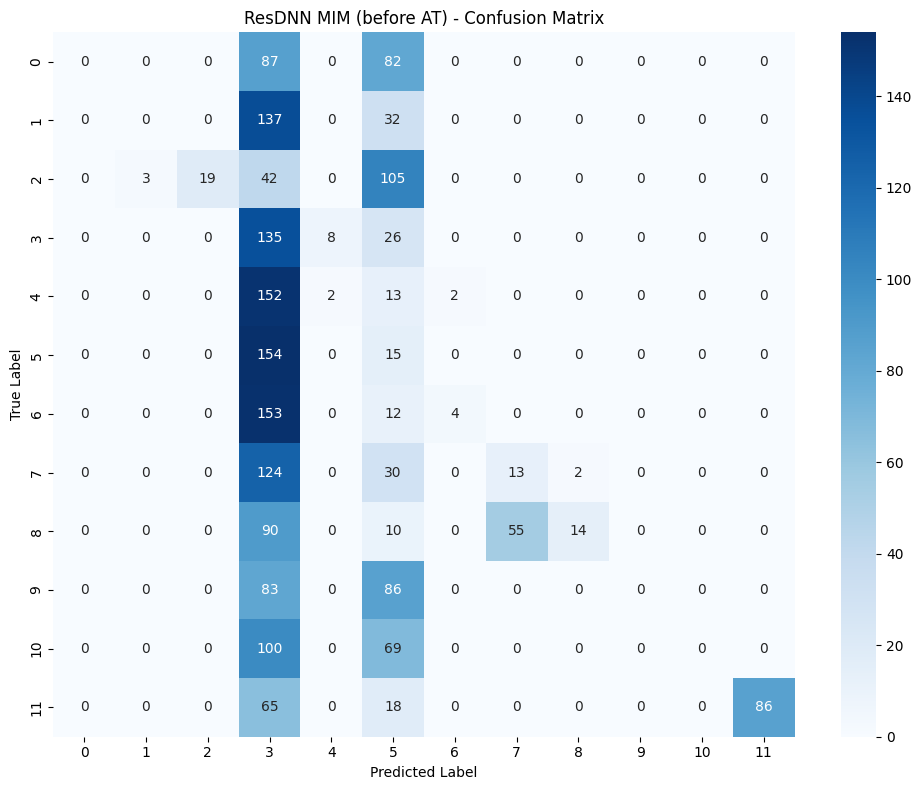

[SKIP] ../../adv_samples/adv_eval/surrogate/surrogate_zoo_adv.csv not found
[SKIP] ../../adv_samples/adv_eval/surrogate/surrogate_hsja_adv.csv not found


In [19]:
ADV_EVAL_DIR = '../../adv_samples/adv_eval/surrogate/'

attack_names = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim', 'zoo', 'hsja']

adv_eval_data = {}

for atk in attack_names:
    path = os.path.join(ADV_EVAL_DIR, f'surrogate_{atk}_adv.csv')
    if os.path.exists(path):
        df_adv = pd.read_csv(path)
        adv_eval_data[atk] = df_adv.drop(columns=['Label']).values.astype(np.float32)
        preds_adv = classifier.predict(adv_eval_data[atk])
        evaluate_attack(y_test, preds_adv, f'{atk.upper()} (before AT)')
    else:
        print(f'[SKIP] {path} not found')

### 5. Generate adversarial samples from training data

In [8]:
# Load training data
df_train = pd.read_csv('../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values.astype(np.float32)
y_train = df_train['Label'].values.astype(int)

print(f'Train set: {X_train.shape}')

Train set: (9600, 66)


#### FGSM on train data

In [9]:
cfg = load_adv_training_config('fgsm')
gen = FGSMAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

os.makedirs('../../adv_samples/adv_training/resdnn', exist_ok=True)
df_adv.to_csv('../../adv_samples/adv_training/resdnn/resdnn_fgsm_train_adv.csv', index=False)

Runtime: 0.71s


#### PGD on train data

In [10]:
cfg = load_adv_training_config('pgd')
gen = PGDAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv('../../adv_samples/adv_training/resdnn/resdnn_pgd_train_adv.csv', index=False)

Runtime: 28.52s


#### DeepFool on train data

In [11]:
cfg = load_adv_training_config('deepfool')
gen = DeepFoolAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv('../../adv_samples/adv_training/resdnn/resdnn_deepfool_train_adv.csv', index=False)

DeepFool: 100%|██████████| 150/150 [00:08<00:00, 17.33it/s]


Runtime: 8.92s


#### CW on train data

In [ ]:
cfg = load_adv_training_config('cw')
gen = CWAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv('../../adv_samples/adv_training/resdnn/resdnn_cw_train_adv.csv', index=False)

#### ZOO on train data

In [12]:
cfg = load_attack_config('zoo')
gen = ZooAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv('../../adv_samples/adv_training/resdnn/resdnn_zoo_train_adv.csv', index=False)

ZOO:   1%|          | 65/9600 [00:09<23:20,  6.81it/s]


KeyboardInterrupt: 

#### HSJA on train_data

In [ ]:
cfg = load_attack_config('hsja')
gen = HSJAAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv('../../adv_samples/adv_training/resdnn/resdnn_hsja_train_adv.csv', index=False)

#### MIM on train data

In [12]:
cfg = load_adv_training_config('mim')
gen = MIMAttackGenerator(classifier, generator_params=cfg)

start_time = time.time()
df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

df_adv.to_csv('../../adv_samples/adv_training/resdnn/resdnn_mim_train_adv.csv', index=False)

Runtime: 23.16s


In [32]:
# ── Directories ──
ADV_TRAIN_DIR = '../../adv_samples/adv_training/resdnn'

# ── Config ──
# CLEAN_ADV_RATIO = 1.5
CLEAN_ADV_RATIO = 0.1
n_clean = len(X_train)
n_adv_budget = int(n_clean / CLEAN_ADV_RATIO)

# Attack list: (name, weight)
# WB_ATTACKS = [  
#     ('fgsm',     4),   # L∞ single-step — giảm                                         
#     ('pgd',      4),   # L∞ iterative — giữ vừa                                        
#     ('deepfool', 1),   # L2 minimal — TĂNG (ASR cao nhất)                              
#     ('cw',       1),   # L2 optimization — tăng (khác pattern với DeepFool)            
#     ('zoo',      1),   # Black-box                                                     
#     ('hsja',     1),   # Black-box decision                                            
#     ('mim',      1),   # L∞ + momentum — transfer tốt                                  
# ]     

# Attack list: (name, weight)
WB_ATTACKS = [  
    ('fgsm',     1.5),   # L∞ single-step — giảm                                         
    ('pgd',      3.0),   # L∞ iterative — giữ vừa                                        
    ('deepfool', 2.5),   # L2 minimal — TĂNG (ASR cao nhất)                              
    ('cw',       1.5),   # L2 optimization — tăng (khác pattern với DeepFool)            
    ('zoo',      1.0),   # Black-box                                                     
    ('hsja',     1.0),   # Black-box decision                                            
    ('mim',      0.5),   # L∞ + momentum — transfer tốt                                  
]     

total_weight = sum(w for _, w in WB_ATTACKS)
rng = np.random.RandomState(42)
parts_X, parts_y = [], []

print('=== White-box adversarial (ResDNN only) ===')
print(f'Budget: {n_adv_budget} (clean={n_clean}, ratio={CLEAN_ADV_RATIO})\n')

for atk_name, weight in WB_ATTACKS:
    path = os.path.join(ADV_TRAIN_DIR, f'resdnn_{atk_name}_train_adv.csv')
    if not os.path.exists(path):
        print(f'  [SKIP] {path}')
        continue

    df = pd.read_csv(path)
    X_atk = df.drop(columns=['Label']).values.astype(np.float32)
    y_atk = df['Label'].values.astype(int)

    n_sample = int(n_adv_budget * weight / total_weight)
    n_sample = min(n_sample, len(X_atk))
    idx = rng.choice(len(X_atk), size=n_sample, replace=False)
    parts_X.append(X_atk[idx])
    parts_y.append(y_atk[idx])
    print(f'  {atk_name:>10s}: {len(X_atk)} -> {n_sample}  (weight={weight})')

# ── Merge & dedup ──
adv_X = np.concatenate(parts_X)
adv_y = np.concatenate(parts_y)

X_train_at = np.concatenate([X_train, adv_X])
y_train_at = np.concatenate([y_train, adv_y])

# Remove exact duplicates
df_tmp = pd.DataFrame(X_train_at)
df_tmp['_lbl'] = y_train_at
n_before = len(df_tmp)
df_tmp = df_tmp.drop_duplicates()
X_train_at = df_tmp.drop(columns=['_lbl']).values.astype(np.float32)
y_train_at = df_tmp['_lbl'].values.astype(int)

print(f'\nClean: {n_clean} | Adv: {len(adv_X)} | Dedup: {n_before - len(df_tmp)}')
print(f'AT train: {X_train_at.shape}')
print(f'\nLabel distribution:\n{pd.Series(y_train_at).value_counts().sort_index()}')

=== White-box adversarial (ResDNN only) ===
Budget: 96000 (clean=9600, ratio=0.1)

        fgsm: 9600 -> 9600  (weight=1.5)
         pgd: 9600 -> 9600  (weight=3.0)
    deepfool: 9600 -> 9600  (weight=2.5)
          cw: 9600 -> 9600  (weight=1.5)
         zoo: 9600 -> 8727  (weight=1.0)
        hsja: 9600 -> 8727  (weight=1.0)
         mim: 9600 -> 4363  (weight=0.5)

Clean: 9600 | Adv: 60217 | Dedup: 5414
AT train: (64403, 66)

Label distribution:
0     4861
1     5330
2     5153
3     5360
4     5367
5     5104
6     5288
7     5727
8     5993
9     5841
10    5748
11    4631
Name: count, dtype: int64


In [33]:
import math
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit

# ===== Scaler mới fit trên clean+adv data =====
scaler_at = StandardScaler()
X_tr_at_sc = scaler_at.fit_transform(X_train_at).astype(np.float32)

# ===== Stratified split 85/15 =====
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, val_idx = next(sss.split(X_tr_at_sc, y_train_at))
X_tr_in, y_tr_in = X_tr_at_sc[tr_idx], y_train_at[tr_idx]
X_val, y_val = X_tr_at_sc[val_idx], y_train_at[val_idx]

# ===== Sampler: balanced =====
counts_tr = np.bincount(y_tr_in, minlength=num_classes).astype(np.float32)
inv = counts_tr.sum() / (counts_tr + 1e-9)
inv /= inv.mean()
sample_w = inv[y_tr_in]
sampler = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

# ===== DataLoaders =====
BATCH_SIZE = 1024
Xtr_t = torch.from_numpy(X_tr_in)
ytr_t = torch.from_numpy(y_tr_in).long()
Xva_t = torch.from_numpy(X_val.astype(np.float32))
yva_t = torch.from_numpy(y_val).long()

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=4096, shuffle=False)

# ===== CB-Focal Loss + Label Smoothing =====
def cb_class_weights(counts, beta=0.999):
    eff = (1.0 - beta) / (1.0 - np.power(beta, counts + 1e-12))
    w = eff / eff.mean()
    return torch.tensor(w, dtype=torch.float32)

class FocalCE(nn.Module):
    def __init__(self, gamma=1.7, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, target):
        n_classes = logits.size(1)
        logp = torch.log_softmax(logits, dim=1)
        p = torch.exp(logp)

        # Label smoothing: target becomes (1-α)*one_hot + α/K
        if self.label_smoothing > 0:
            smooth = self.label_smoothing / n_classes
            one_hot = torch.zeros_like(logp).scatter_(1, target.unsqueeze(1), 1.0)
            soft_target = one_hot * (1.0 - self.label_smoothing) + smooth
        else:
            soft_target = torch.zeros_like(logp).scatter_(1, target.unsqueeze(1), 1.0)

        # Focal modulation on the true class
        idx = torch.arange(logits.size(0), device=logits.device)
        pt = p[idx, target]
        focal_weight = (1 - pt) ** self.gamma

        # Weighted cross entropy with soft targets
        loss = -(soft_target * logp).sum(dim=1) * focal_weight

        if self.weight is not None:
            loss = loss * self.weight.to(logits.device)[target]
        return loss.mean()

LABEL_SMOOTHING = 0.05
cls_w = cb_class_weights(counts_tr, beta=0.999).to(DEVICE)
criterion = FocalCE(gamma=1.7, weight=cls_w, label_smoothing=LABEL_SMOOTHING)
print(f'Label smoothing: {LABEL_SMOOTHING}')

# ===== Optimizer + Warmup+Cosine scheduler =====
torch.manual_seed(42)
resdnn_at = _ResDNN(in_dim=input_dim, n_classes=num_classes).to(DEVICE)

total_epochs = 200
warmup_epochs = 8
LR = 1e-3

optimizer = torch.optim.AdamW(resdnn_at.parameters(), lr=LR, weight_decay=2e-4)

steps_per_epoch = max(1, len(train_loader))
def lr_lambda(current_step):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch
    if current_step < warmup_steps:
        return (current_step + 1) / warmup_steps
    progress = (current_step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ===== Training loop: early stop on Macro-F1 =====
best_f1, best_state, wait, patience = -1.0, None, 0, 20

for epoch in range(total_epochs):
    resdnn_at.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = resdnn_at(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(resdnn_at.parameters(), 3.0)
        optimizer.step()
        scheduler.step()

    # Eval VAL
    resdnn_at.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            preds = torch.argmax(resdnn_at(xb.to(DEVICE)), dim=1).cpu().numpy()
            all_preds.extend(preds)

    val_f1 = f1_score(y_val, all_preds, average='macro', zero_division=0)

    if val_f1 > best_f1:
        best_f1, wait = val_f1, 0
        best_state = {k: v.detach().cpu().clone() for k, v in resdnn_at.state_dict().items()}
    else:
        wait += 1

    if wait >= patience:
        print(f'Early stop at epoch {epoch + 1} | best VAL Macro-F1 = {best_f1:.4f}')
        break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{total_epochs}, val_f1={val_f1:.4f}')

# Load best checkpoint
if best_state is not None:
    resdnn_at.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()}, strict=True)
resdnn_at.eval()
print(f'Training done. Best val F1: {best_f1:.4f}')

Label smoothing: 0.05
Epoch 10/200, val_f1=0.6049
Epoch 20/200, val_f1=0.6231
Epoch 30/200, val_f1=0.6652
Epoch 40/200, val_f1=0.6677
Epoch 50/200, val_f1=0.6829
Epoch 60/200, val_f1=0.6887
Epoch 70/200, val_f1=0.6868
Epoch 80/200, val_f1=0.6669
Epoch 90/200, val_f1=0.7046
Epoch 100/200, val_f1=0.7005
Epoch 110/200, val_f1=0.7064
Epoch 120/200, val_f1=0.7051
Epoch 130/200, val_f1=0.7040
Epoch 140/200, val_f1=0.7079
Epoch 150/200, val_f1=0.7093
Epoch 160/200, val_f1=0.7108
Epoch 170/200, val_f1=0.7116
Epoch 180/200, val_f1=0.7136
Epoch 190/200, val_f1=0.7166
Epoch 200/200, val_f1=0.7086
Training done. Best val F1: 0.7190


In [10]:
# Save adversarially-trained checkpoint (giống format gốc)
os.makedirs('../../defense/models', exist_ok=True)
out_path = '../../defense/models/framework_resdnn_TVAE_at.pth'

torch.save({
    'state_dict':   resdnn_at.state_dict(),
    'in_dim':       input_dim,
    'n_classes':    num_classes,
    'scaler':       scaler_at,  # save cả object giống model gốc
    'scaler_mean':  scaler_at.mean_,
    'scaler_scale': scaler_at.scale_,
}, out_path)
print(f'Saved: {out_path}')

Saved: ../../defense/models/framework_resdnn_TVAE_at.pth


### 7. Evaluate retrained model

--- Original (after AT) ---
Accuracy: 62.72%
Precision: 63.59%
Recall: 62.72%
F1 Score: 0.6190


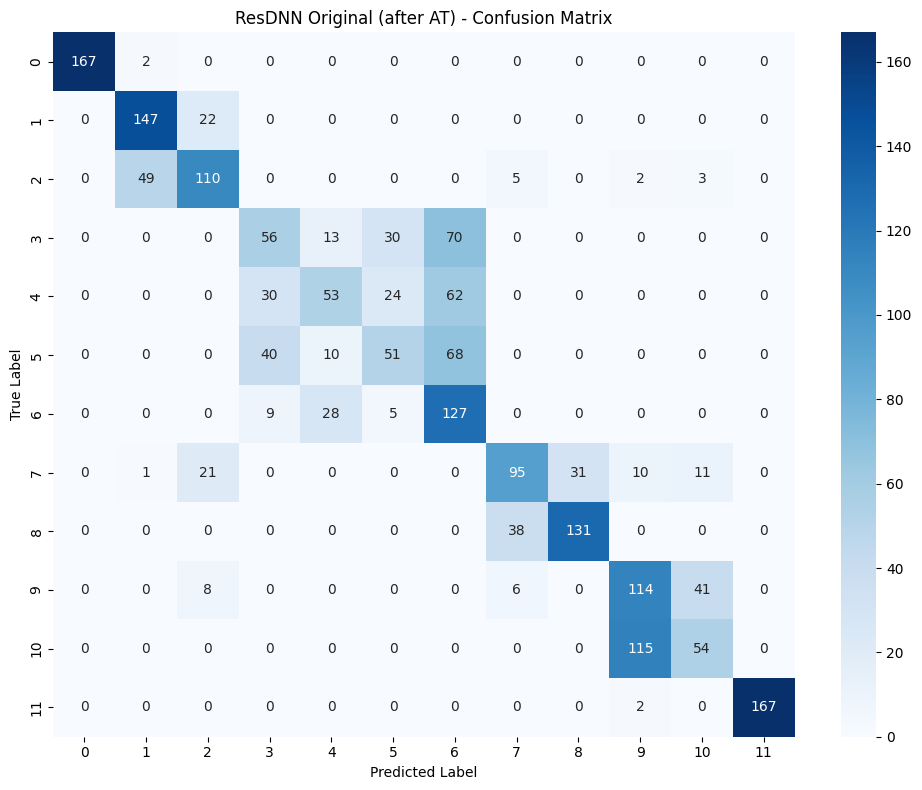

--- FGSM (after AT) ---
Accuracy: 68.34%
Precision: 69.17%
Recall: 68.34%
F1 Score: 0.6758


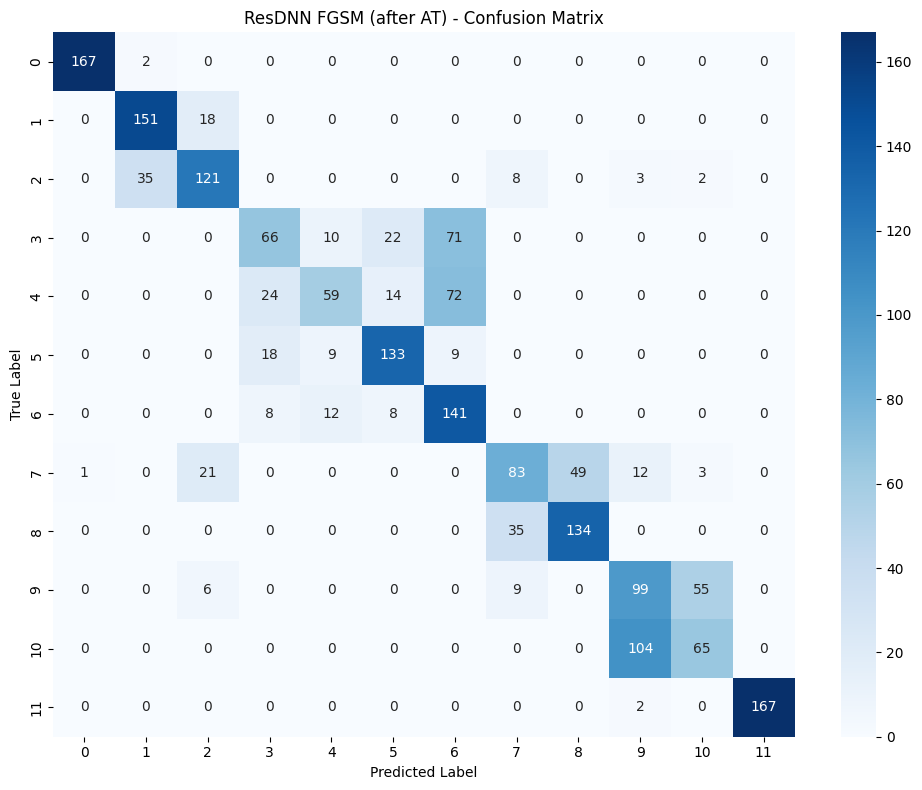

--- PGD (after AT) ---
Accuracy: 59.52%
Precision: 60.28%
Recall: 59.52%
F1 Score: 0.5935


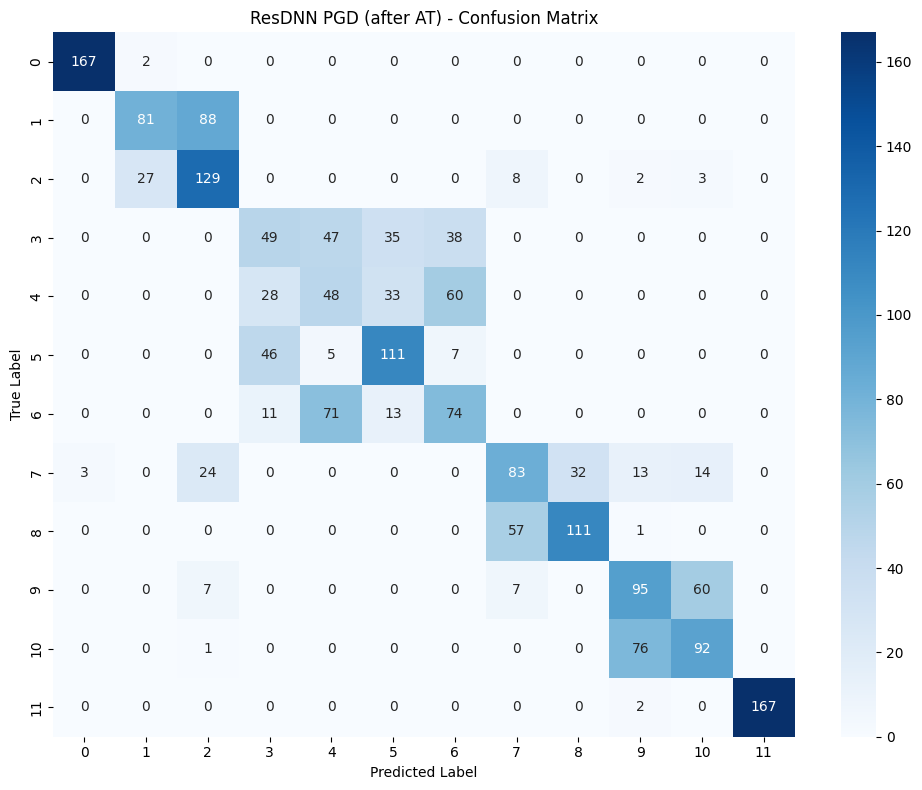

--- DEEPFOOL (after AT) ---
Accuracy: 50.30%
Precision: 49.73%
Recall: 50.30%
F1 Score: 0.4838


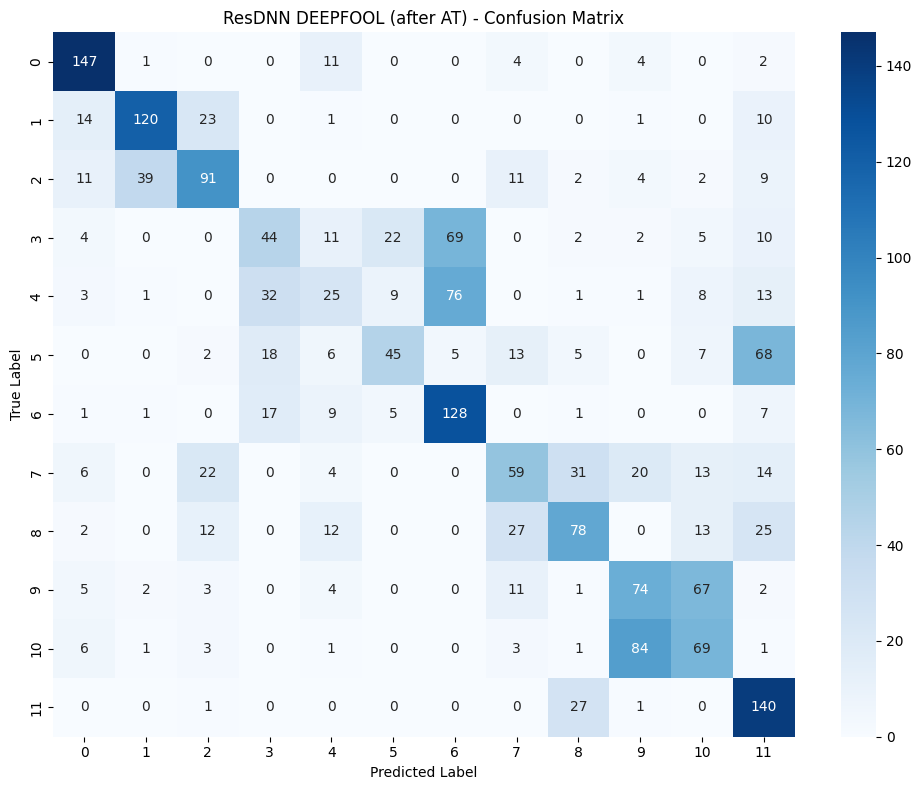

--- CW (after AT) ---
Accuracy: 62.87%
Precision: 63.76%
Recall: 62.87%
F1 Score: 0.6205


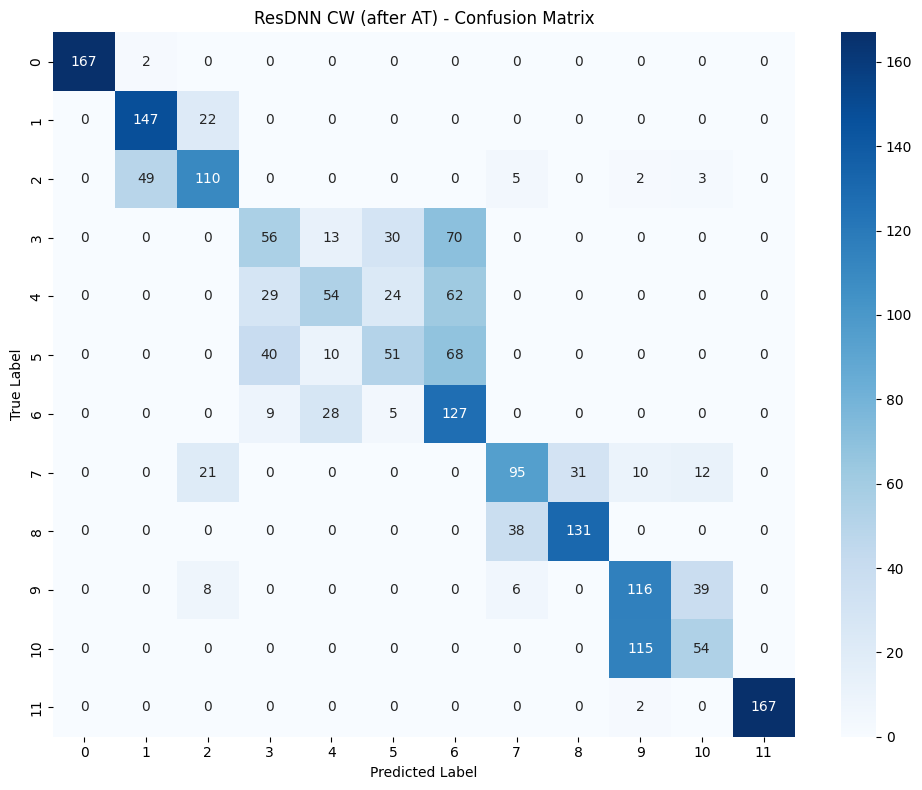

--- ZOO (after AT) ---
Accuracy: 63.66%
Precision: 64.31%
Recall: 63.66%
F1 Score: 0.6339


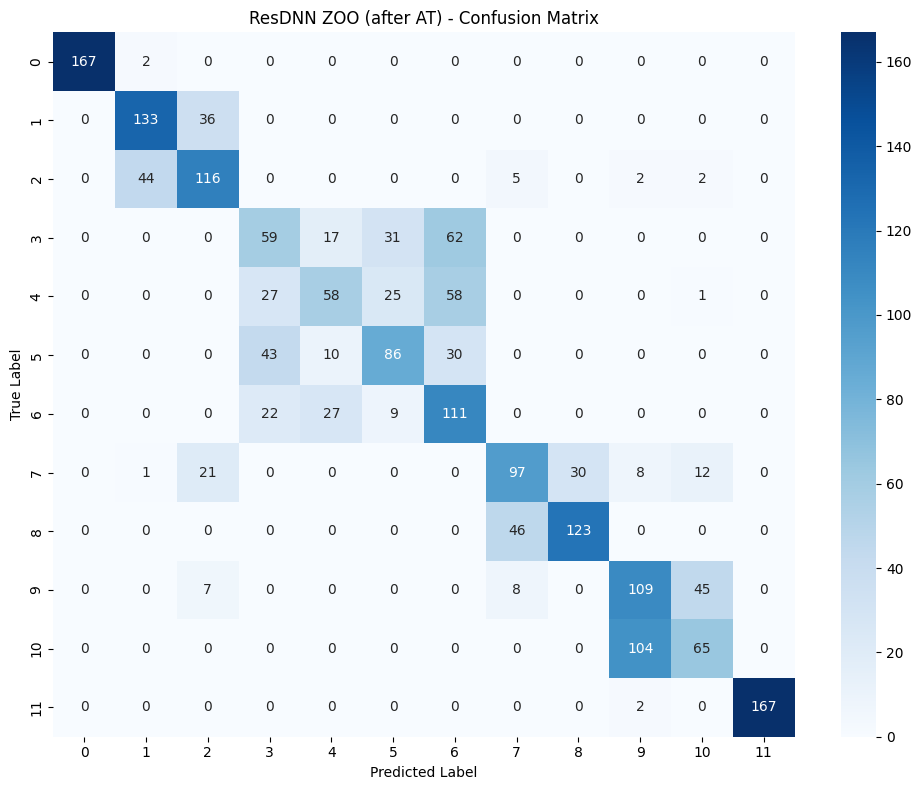

--- HSJA (after AT) ---
Accuracy: 62.82%
Precision: 63.64%
Recall: 62.82%
F1 Score: 0.6197


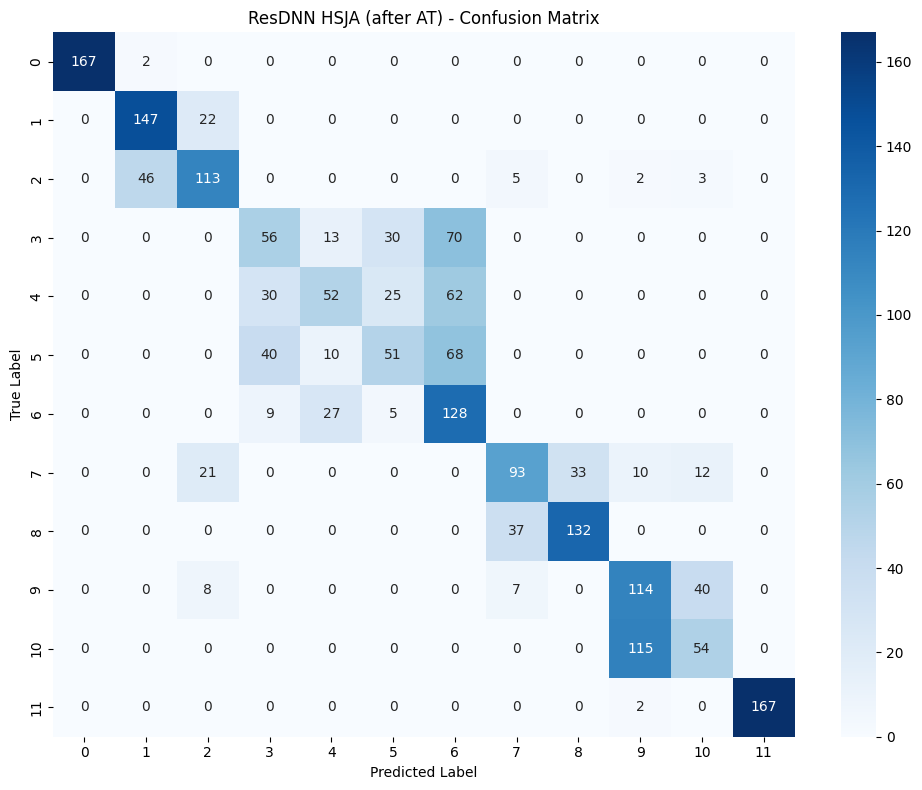

In [29]:
# ── Load retrained AT model ──
ckpt_at = torch.load(out_path, map_location=DEVICE, weights_only=False)

resdnn_at_net = _ResDNN(
    in_dim=int(ckpt_at['in_dim']),
    n_classes=int(ckpt_at['n_classes']),
)
resdnn_at_net.load_state_dict(ckpt_at['state_dict'])
resdnn_at_net.eval()

scaled_model_at = _ScaledResDNN(resdnn_at_net, ckpt_at['scaler_mean'], ckpt_at['scaler_scale']).to(DEVICE)
scaled_model_at.eval()

classifier_at = PyTorchClassifier(
    model=scaled_model_at,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

# Evaluate on original test data
preds_orig = classifier_at.predict(X_test)
evaluate_attack(y_test, preds_orig, 'Original (after AT)')

# Evaluate on each adversarial test set
for atk, adv_data in adv_eval_data.items():
    preds_adv = classifier_at.predict(adv_data)
    evaluate_attack(y_test, preds_adv, f'{atk.upper()} (after AT)')

In [30]:
# Before AT
preds_before = classifier.predict(X_test)
y_pred_before = np.argmax(preds_before, axis=1)
correct_before = np.where(y_test == y_pred_before)[0]

# After AT
preds_after = classifier_at.predict(X_test)
y_pred_after = np.argmax(preds_after, axis=1)
correct_after = np.where(y_test == y_pred_after)[0]

print('=== ResDNN ASR Comparison (Before AT -> After AT) ===')
for atk, adv_data in adv_eval_data.items():
    # Before AT
    preds_adv_b = np.argmax(classifier.predict(adv_data), axis=1)
    asr_before = np.sum(y_pred_before[correct_before] != preds_adv_b[correct_before]) / len(correct_before) * 100

    # After AT
    preds_adv_a = np.argmax(classifier_at.predict(adv_data), axis=1)
    asr_after = np.sum(y_pred_after[correct_after] != preds_adv_a[correct_after]) / len(correct_after) * 100

    print(f'{atk.upper():>10s} ASR: {asr_before:.2f}% -> {asr_after:.2f}%')

=== ResDNN ASR Comparison (Before AT -> After AT) ===
      FGSM ASR: 72.37% -> 7.08%
       PGD ASR: 87.33% -> 24.61%
  DEEPFOOL ASR: 100.00% -> 29.32%
        CW ASR: 53.40% -> 0.08%
       ZOO ASR: 98.71% -> 7.70%
      HSJA ASR: 93.84% -> 0.24%
